# 5 — Visualización orientada a preguntas

Un gráfico no es el objetivo: es evidencia para responder una pregunta. En cada ejercicio primero escribí qué querés averiguar, luego construí la agregación y finalmente redactá una conclusión de dos o tres oraciones.

Este notebook se ejecuta manualmente **después** de que el Job termina correctamente; no forma parte del pipeline.

In [0]:
dbutils.widgets.text("student_id", "alumno01", "01 - Identificador")
dbutils.widgets.dropdown("scale", "small", ["test", "small", "demo"], "02 - Escala")

In [0]:
%run ../common/config

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

catalog = spark.sql("SELECT current_catalog()").first()[0]
config = CourseConfig(catalog, dbutils.widgets.get("student_id"), dbutils.widgets.get("scale"))
daily = qualified_table(config, "gold_daily_sales")
risk = qualified_table(config, "gold_customer_risk")
batch = qualified_table(config, "gold_batch_summary")
for table in [daily, risk, batch]:
    assert spark.catalog.tableExists(table), f"Falta {table}. Ejecutá primero el Job completo."

In [0]:
def wilson(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / denom
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centro - margen, centro + margen

## Ejemplo resuelto

**Pregunta:** ¿Qué categoría concentra el mayor monto vendido?

La agregación se hace con Spark. Sólo el resultado pequeño se convierte a Pandas para dibujarlo. Un gráfico de barras ordenado permite comparar categorías; un gráfico de torta haría más difícil comparar valores cercanos.

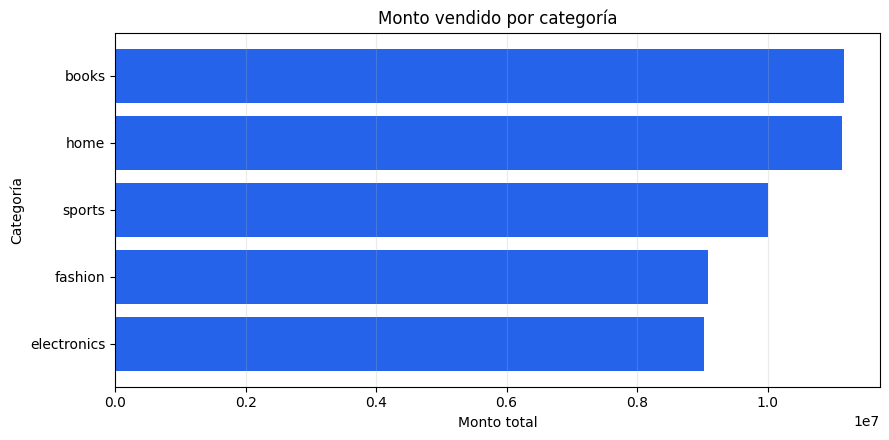

Respuesta: books es la categoría con mayor monto vendido (11,165,281.86).


In [0]:
category_sales = (spark.table(daily)
    .groupBy("category")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy(F.desc("total_amount")))

plot_data = category_sales.toPandas().sort_values("total_amount")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_data["category"], plot_data["total_amount"], color="#2563eb")
ax.set_title("Monto vendido por categoría")
ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

leader = category_sales.first()
print(f"Respuesta: {leader.category} es la categoría con mayor monto vendido ({leader.total_amount:,.2f}).")

## Consigna 1 — Evolución temporal

**Pregunta:** ¿Qué día tuvo el mayor monto vendido y ese día también fue el de mayor cantidad de transacciones?

Construí una visualización temporal que permita comparar ambas métricas sin ocultar sus unidades. Explicá si los dos máximos coinciden y qué implica que coincidan —o no— sobre el ticket promedio. Fuente sugerida: `gold_daily_sales`.

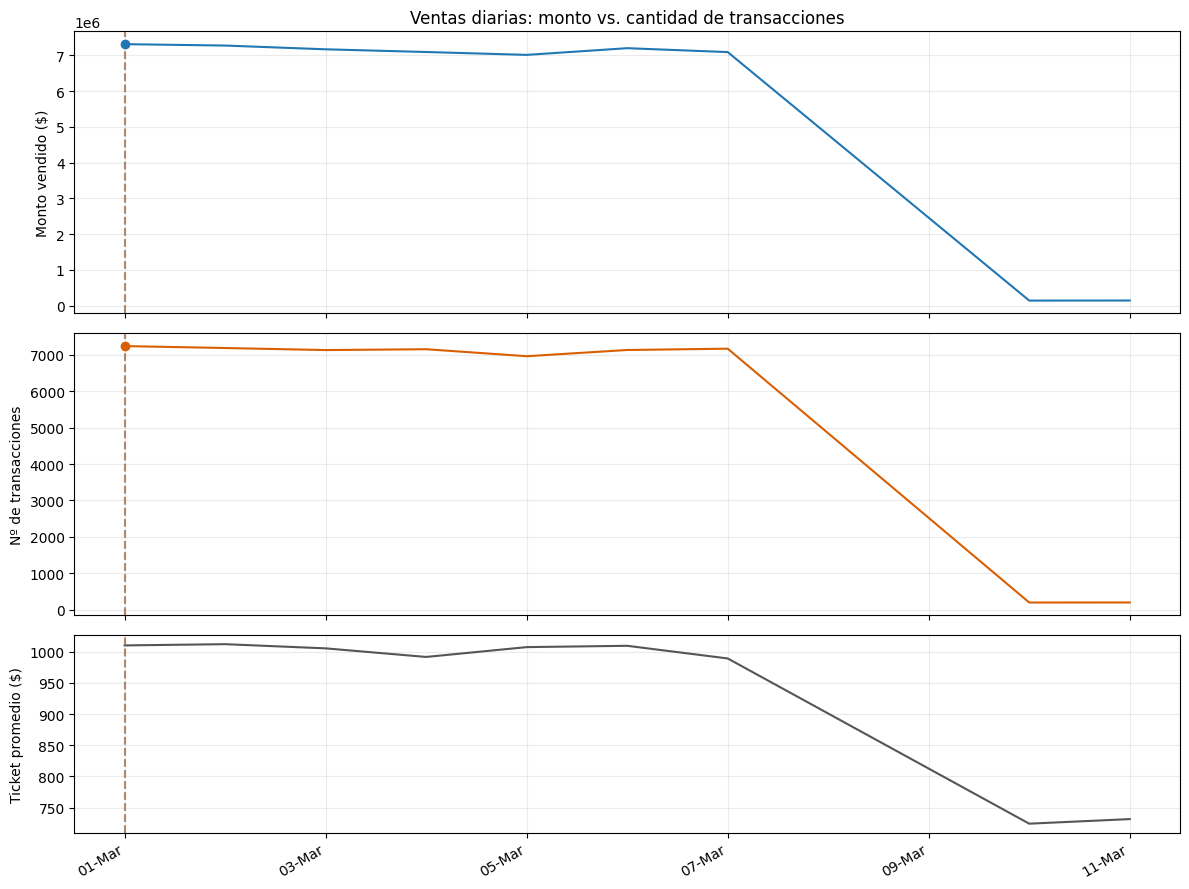

Día de mayor monto:          2026-03-01  -> $7,310,841
Día de más transacciones:    2026-03-01  -> 7,236
¿Coinciden?                  True
Ticket promedio ese día (monto): $1,010.34
Ticket promedio del período:     $1,001.63


In [0]:
# Tu solución. Agregá por sale_date antes de convertir el resultado a Pandas.
# Incluí título, ejes, unidades y una respuesta escrita.

resultado_1 = (
    spark.table(daily)
    .groupBy("sale_date")
    .agg(
        F.sum("total_amount").alias("total_amount"),
        F.sum("transaction_count").alias("transactions"),
    )
    .withColumn("avg_ticket", F.col("total_amount") / F.col("transactions"))
    .orderBy("sale_date")
    .toPandas()
)

resultado_1["sale_date"] = pd.to_datetime(resultado_1["sale_date"])

df = resultado_1.sort_values("sale_date")

idx_monto = df["total_amount"].idxmax()
idx_trx   = df["transactions"].idxmax()
dia_monto = df.loc[idx_monto, "sale_date"]
dia_trx   = df.loc[idx_trx, "sale_date"]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 0.7]})

# Gráfico 1: montos totales por día
axes[0].plot(df["sale_date"], df["total_amount"], color="#1f77b4")
axes[0].scatter(dia_monto, df.loc[idx_monto, "total_amount"], color="#1f77b4", zorder=5)
axes[0].set_ylabel("Monto vendido ($)")
axes[0].set_title("Ventas diarias: monto vs. cantidad de transacciones")

# Gráfico 2: cantidad de transacciones por día
axes[1].plot(df["sale_date"], df["transactions"], color="#d95f02")
axes[1].scatter(dia_trx, df.loc[idx_trx, "transactions"], color="#d95f02", zorder=5)
axes[1].set_ylabel("Nº de transacciones")

# Gráfico 3: ticket promedio
axes[2].plot(df["sale_date"], df["avg_ticket"], color="#555555")
axes[2].set_ylabel("Ticket promedio ($)")

for ax in axes:
    ax.axvline(dia_monto, color="#1f77b4", ls="--", alpha=.5)
    ax.axvline(dia_trx,   color="#d95f02", ls="--", alpha=.5)
    ax.grid(alpha=.25)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

coinciden = dia_monto == dia_trx

print(f"Día de mayor monto:          {dia_monto.date()}  -> ${df.loc[idx_monto,'total_amount']:,.0f}")
print(f"Día de más transacciones:    {dia_trx.date()}  -> {df.loc[idx_trx,'transactions']:,.0f}")
print(f"¿Coinciden?                  {coinciden}")
print(f"Ticket promedio ese día (monto): ${df.loc[idx_monto,'avg_ticket']:,.2f}")
print(f"Ticket promedio del período:     ${df['total_amount'].sum()/df['transactions'].sum():,.2f}")

Como el ticket promedio es: monto / transacciones, las dos métricas y el ticket están relacionados. Frente a esto, existen dos escenarios posibles:

1. Si los máximos (máx. monto y máx. transacciones) coinciden: el día de mayor facturación fue impulsado por el volumen de clientes. El ticket promedio de ese día debería estar cerca del promedio del período. El récord de ventas se explica por cantidad de clientes y no porque cada cliente gastara más.
2. Si no coinciden: el ticket promedio varió ese día, y hay dos casos:
    1. Si el día de mayor monto no tiene el mayor número de transacciones, entonces el ticket promedio de ese día estuvo por encima de lo normal. Las ventas se explican por compras más grandes.
    2. Si el día de más transacciones no tiene el mayor monto, entonces su ticket promedio fue bajo. Pasó que mucha gente compró, pero cosas baratas.

## Consigna 2 — Canal y fraude

**Pregunta:** ¿Qué canal de pago presenta la mayor tasa de fraude? ¿La conclusión se sostiene al considerar el número de transacciones de cada canal?

Mostrá tasa y volumen de manera legible. No compares sólo cantidades de fraude: calculá el denominador correcto. Fuente sugerida: `gold_daily_sales`.

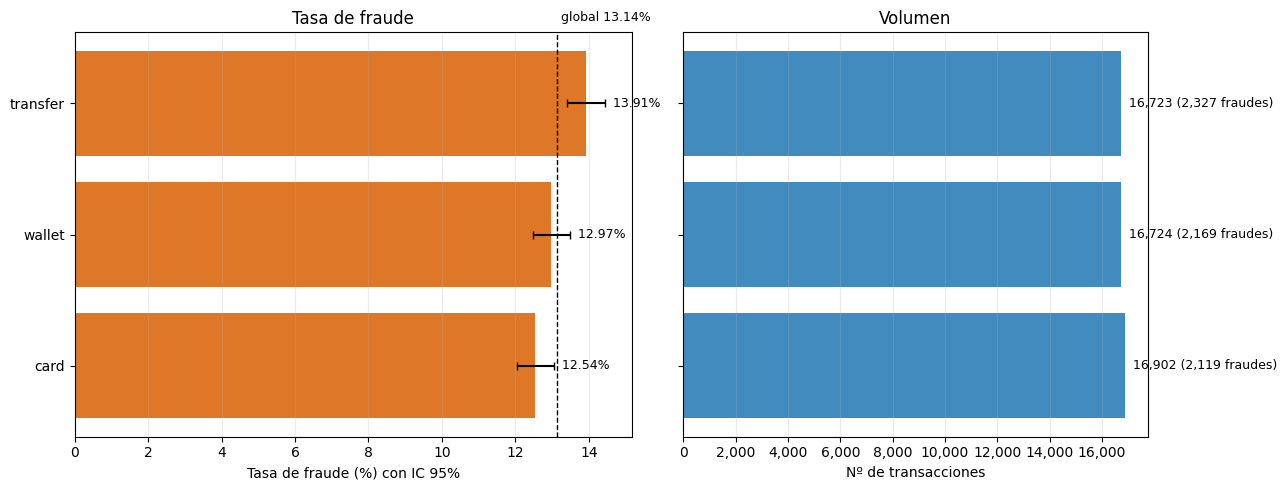

payment_channel  fraud_transactions  transaction_count  fraud_rate_percentage              ic95
       transfer                2327              16723                 13.915 [13.40% – 14.45%]
         wallet                2169              16724                 12.969 [12.47% – 13.49%]
           card                2119              16902                 12.537 [12.05% – 13.04%]

Tasa global (suma/suma): 13.138%

Mayor tasa: transfer | Segundo: wallet
Intervalos se solapan: True
Canal con más fraudes absolutos: transfer | ¿coincide con mayor tasa?: True


In [0]:
# Tu solución. Recalculá la tasa global como suma(fraud_transactions) / suma(transaction_count).
# Evitá promediar directamente fraud_rate entre grupos.

canales = (spark.table(daily)
           .groupBy("payment_channel")
           .agg(
               F.sum("fraud_transactions").alias("fraud_transactions"),
               F.sum("transaction_count").alias("transaction_count"),
           )
           .filter(F.col("transaction_count") > 0)
           .withColumn("fraud_rate", F.col("fraud_transactions") / F.col("transaction_count"))
           .toPandas()
           )

tasa_global = canales["fraud_transactions"].sum() / canales["transaction_count"].sum()           

# Intervalo de confianza de Wilson del 95% para evaluar el efecto del volumen

canales["ci_low"], canales["ci_high"] = wilson(
    canales["fraud_transactions"], canales["transaction_count"]
)
canales = canales.sort_values("fraud_rate", ascending=True).reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True,
                               gridspec_kw={"width_ratios": [1.2, 1]})
y = np.arange(len(canales))

# Izquierda: tasa de fraude con IC 95%
err = np.array([canales["fraud_rate"] - canales["ci_low"],
                canales["ci_high"] - canales["fraud_rate"]])
ax1.barh(y, canales["fraud_rate"] * 100, xerr=err * 100,
         color="#d95f02", alpha=.85, capsize=3)
ax1.axvline(tasa_global * 100, color="black", ls="--", lw=1)
ax1.text(tasa_global * 100, len(canales) - 0.4,
         f" global {tasa_global:.2%}", va="bottom", fontsize=9)
ax1.set_yticks(y)
ax1.set_yticklabels(canales["payment_channel"])
ax1.set_xlabel("Tasa de fraude (%) con IC 95%")
ax1.set_title("Tasa de fraude")
for i, r in canales.iterrows():
    ax1.text(r["ci_high"] * 100, i, f"  {r['fraud_rate']:.2%}", va="center", fontsize=9)

# Derecha: volumen
ax2.barh(y, canales["transaction_count"], color="#1f77b4", alpha=.85)
ax2.set_xlabel("Nº de transacciones")
ax2.set_title("Volumen")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
for i, r in canales.iterrows():
    ax2.text(r["transaction_count"], i,
             f"  {r['transaction_count']:,.0f} ({int(r['fraud_transactions']):,} fraudes)",
             va="center", fontsize=9)

for ax in (ax1, ax2):
    ax.grid(axis="x", alpha=.25)
plt.tight_layout()
plt.show()

ordenado = canales.sort_values("fraud_rate", ascending=False)

tabla = ordenado.assign(
    fraud_rate_percentage=lambda d: (d["fraud_rate"] * 100).round(3),
    ic95=lambda d: d.apply(lambda r: f"[{r.ci_low:.2%} – {r.ci_high:.2%}]", axis=1),
)[["payment_channel", "fraud_transactions", "transaction_count", "fraud_rate_percentage", "ic95"]]

print(tabla.to_string(index=False))
print(f"\nTasa global (suma/suma): {tasa_global:.3%}")

top, segundo = ordenado.iloc[:2].to_dict("records")
print(f"\nMayor tasa: {top['payment_channel']} | Segundo: {segundo['payment_channel']}")
print("Intervalos se solapan:", top["ci_low"] <= segundo["ci_high"])

mas_fraudes = canales.loc[canales["fraud_transactions"].idxmax(), "payment_channel"]
print(f"Canal con más fraudes absolutos: {mas_fraudes} | ¿coincide con mayor tasa?: {mas_fraudes == top['payment_channel']}")

**¿Qué canal de pago presenta la mayor tasa de fraude?**

Como se puede observar en la tabla propuesta, el canal de pago que presenta la mayor tasa de fraude es `transfer` 

**¿La conclusión se sostiene al considerar el número de transacciones de cada canal?**

El volumen no distorsiona la comparación. Los tres canales presentan una cantidad casi idéntica de transacciones, así que ninguna tasa se apoya en una muestra más chica que las otras. Los intervalos son angostos, por lo que ninguna tasa es inestable. Además, `transfer` también tiene más fraudes absolutos (2.327), de modo que ranking absoluto y ranking por tasa coinciden. Con volúmenes tan parejos, eso es esperable.

## Consigna 3 — Concentración geográfica y de producto

**Pregunta:** ¿Qué combinación de país y categoría genera el mayor monto? ¿Existe una categoría dominante en todos los países o cambia según el mercado?

Elegí una visualización que permita comparar simultáneamente países y categorías. Justificá brevemente por qué ese tipo de gráfico es adecuado. Fuente sugerida: `gold_daily_sales`.

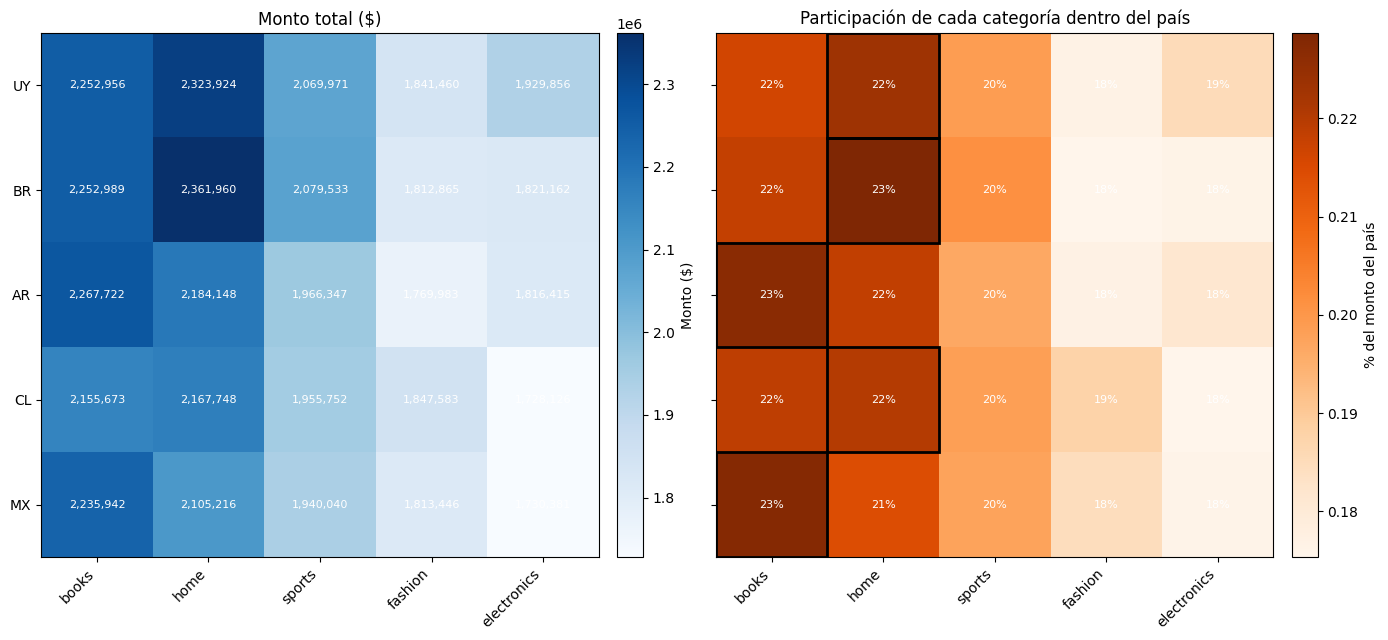

Máximo global: BR y home -> $2,361,960 (4.7% del total)

         categoria_dominante       monto  participacion (%)
country                                                   
UY                     home  2323924.46               22.3
BR                     home  2361959.97               22.9
AR                    books  2267722.26               22.7
CL                     home  2167748.03               22.0
MX                    books  2235941.63               22.8

Categorías distintas que lideran: 2
Dominante global (todos los países): False

Margen 1era vs 2da categoría (pp):
 country
UY    0.7
BR    1.1
AR    0.8
CL    0.1
MX    1.3


In [0]:
# Tu solución. Algunas opciones: mapa de calor o barras agrupadas.
# La conclusión debe mencionar tanto el máximo global como las diferencias entre países.


pais_cat = (spark.table(daily)
            .groupBy("country", "category")
            .agg(F.sum("total_amount").cast("double").alias("total_amount"))
            .toPandas()
            )

# Matriz país x categoría
matriz = pais_cat.pivot(index="country", columns="category", values="total_amount").fillna(0)

# Ordenamiento: países por monto total (de mayor a menor), categorías por monto total
matriz = matriz.loc[matriz.sum(axis=1).sort_values(ascending=False).index,
                    matriz.sum(axis=0).sort_values(ascending=False).index]

share = matriz.div(matriz.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 0.6 * len(matriz) + 3.5), sharey=True)

def heat(ax, data, fmt, cmap, title, cbar_label):
    im = ax.imshow(data.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(data.shape[1]))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(data.shape[0]))
    ax.set_yticklabels(data.index)
    ax.set_title(title)
    umbral = data.values.max() * 0.6
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.values[i, j]
            ax.text(j, i, fmt(v), ha="center", va="center", fontsize=8,
                    color="white" if v > umbral else "black")
    plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.046, pad=0.03)

heat(axes[0], matriz, lambda v: f"{v:,.0f}", "Blues",
     "Monto total ($)", "Monto ($)")
heat(axes[1], share, lambda v: f"{v:.0%}", "Oranges",
     "Participación de cada categoría dentro del país", "% del monto del país")

for i, pais in enumerate(share.index):
    j = share.values[i].argmax()
    axes[1].add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, ec="black", lw=2))

plt.tight_layout()
plt.show()

pais_max, cat_max = matriz.stack().idxmax()
monto_max = matriz.stack().max()
print(f"Máximo global: {pais_max} y {cat_max} -> ${monto_max:,.0f} "
      f"({monto_max / matriz.values.sum():.1%} del total)")

cat_dominante = pd.DataFrame({
    "categoria_dominante": matriz.idxmax(axis=1),
    "monto": matriz.max(axis=1),
    "participacion (%)": share.max(axis=1).round(3) * 100,
})
print("\n", cat_dominante.to_string())

# ¿Hay una categoría dominante en todos los países?
unicas = cat_dominante["categoria_dominante"].nunique()
print(f"\nCategorías distintas que lideran: {unicas}")
print("Dominante global (todos los países):", unicas == 1)

# Margen entre 1era y 2da categoría de cada país
margen = share.apply(lambda r: r.nlargest(2).iloc[0] - r.nlargest(2).iloc[1], axis=1)
print("\nMargen 1era vs 2da categoría (pp):\n", (margen * 100).round(1).to_string())

Para representar gráficamente esta consigna elegí el mapa de calor ya que con N países × M categorías, las barras agrupadas generan N×M barras, difíciles de leer y de comparar. En cambio, el mapa de calor muestra todas las combinaciones en una grilla compacta donde se puede detectar enseguida el máximo y los patrones por fila o columna. Además, propuse dos paneles: monto absoluto que responde "¿qué combinación es la mayor?" y participación dentro de cada país que responde "¿la categoría dominante cambia según el mercado?".

**¿Qué combinación de país y categoría genera el mayor monto?** 

La combinación de país y categoría que genera el mayor monto es Brasil y home, con un monto de $2,361,960. 

**¿Existe una categoría dominante en todos los países o cambia según el mercado?**

No, no existe una categoría dominante en todos los mercados: home lidera en Uruguay, Brasil y Chile, y books en Argentina y México.

## Consigna 4 — Calidad del pipeline

**Pregunta:** ¿Qué proporción de cada lote fue aceptada y rechazada? ¿El lote nuevo presenta una calidad diferente del lote inicial?

Compará lotes usando proporciones además de cantidades absolutas. Señalá cualquier limitación de comparar lotes de tamaños distintos. Fuente sugerida: `gold_batch_summary`.

source_batch_id  accepted  rejected   total  accepted_rate  rejected_rate
      batch_002     200.0       2.0   202.0       0.990099       0.009901
      batch_003     201.0       2.0   203.0       0.990148       0.009852
        initial   49948.0      51.0 49999.0       0.998980       0.001020


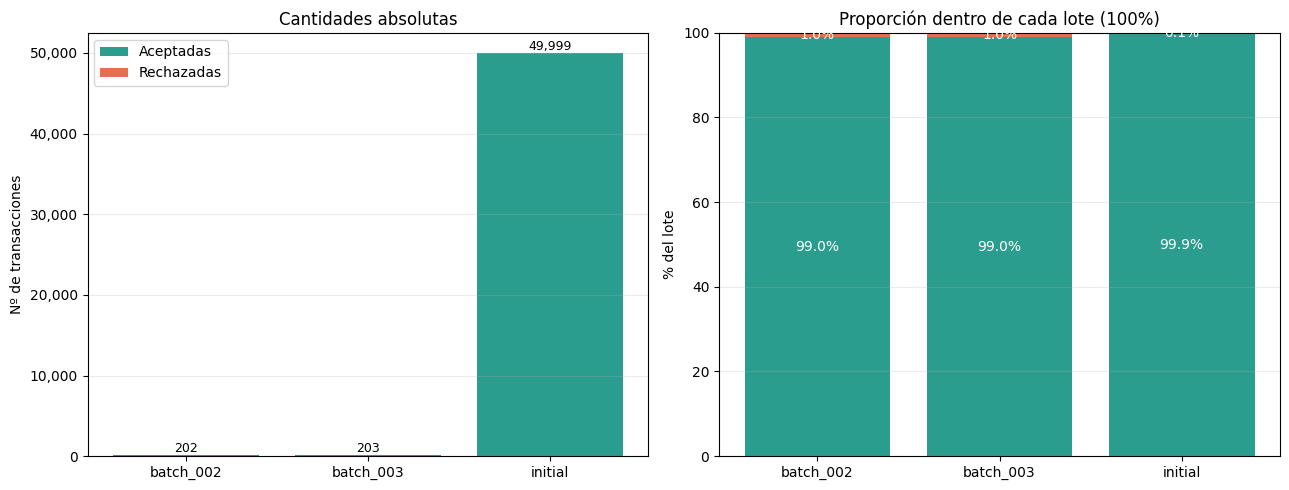

In [0]:
# Tu solución. Calculá total = accepted_transactions + rejected_transactions.
# Un gráfico de barras apiladas al 100% puede facilitar la comparación de proporciones.
lotes = (
    spark.table(batch)
    .groupBy("source_batch_id")
    .agg(
        F.sum("accepted_transactions").alias("accepted"),
        F.sum("rejected_transactions").alias("rejected"),
    )
    .withColumn("total", F.col("accepted") + F.col("rejected"))
    .filter(F.col("total") > 0)
    .withColumn("accepted_rate", F.col("accepted") / F.col("total"))
    .withColumn("rejected_rate", F.col("rejected") / F.col("total"))
    .orderBy("source_batch_id")
    .toPandas()
)

for c in ["accepted", "rejected", "total", "accepted_rate", "rejected_rate"]:
    lotes[c] = lotes[c].astype(float)

print(lotes.to_string(index=False))

# Intervalo de confianza para la tasa de rechazo
lotes["ci_low"], lotes["ci_high"] = wilson(lotes["rejected"].values, lotes["total"].values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(lotes))
etiquetas = lotes["source_batch_id"].astype(str)

# Izquierda: cantidades absolutas apiladas
ax1.bar(x, lotes["accepted"], color="#2a9d8f", label="Aceptadas")
ax1.bar(x, lotes["rejected"], bottom=lotes["accepted"], color="#e76f51", label="Rechazadas")
ax1.set_xticks(x); ax1.set_xticklabels(etiquetas)
ax1.set_ylabel("Nº de transacciones")
ax1.set_title("Cantidades absolutas")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
for i, r in lotes.iterrows():
    ax1.text(i, r["total"], f"{r['total']:,.0f}", ha="center", va="bottom", fontsize=9)
ax1.legend()

# Derecha: apiladas al 100%
ax2.bar(x, lotes["accepted_rate"] * 100, color="#2a9d8f", label="Aceptadas")
ax2.bar(x, lotes["rejected_rate"] * 100, bottom=lotes["accepted_rate"] * 100,
        color="#e76f51", label="Rechazadas")
ax2.set_xticks(x); ax2.set_xticklabels(etiquetas)
ax2.set_ylabel("% del lote")
ax2.set_ylim(0, 100)
ax2.set_title("Proporción dentro de cada lote (100%)")
for i, r in lotes.iterrows():
    ax2.text(i, r["accepted_rate"] * 50, f"{r['accepted_rate']:.1%}",
             ha="center", va="center", color="white", fontsize=10)
    ax2.text(i, r["accepted_rate"] * 100 + r["rejected_rate"] * 50, f"{r['rejected_rate']:.1%}",
             ha="center", va="center", color="white", fontsize=10)

for ax in (ax1, ax2):
    ax.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.show()


**¿Qué proporción de cada lote fue aceptada y rechazada?** 

En los tres lotes la gran mayoría de las transacciones fue aceptada: 99,90% en el lote inicial y 99,01% en batch_002 y batch_003. Sin embargo, la tasa de rechazo de los lotes nuevos (~0,99%) es aproximadamente diez veces la del lote inicial (0,10%).

**¿El lote nuevo presenta una calidad diferente del lote inicial?**

Los lotes nuevos tienen una calidad peor en términos relativos, aunque el nivel de rechazo sigue siendo bajo en términos absolutos. Aunque esta conclusión se ve limitada ya que cada lote nuevo tiene solo aproximadamente 200 transacciones y 2 rechazos, por lo que la tasa real está estimada con poca precisión.

## Criterios de entrega

Para cada consigna entregá: (1) la transformación de datos, (2) un gráfico, y (3) una conclusión de dos o tres oraciones que responda explícitamente la pregunta.

Cada gráfico debe tener título informativo, ejes y unidades legibles, categorías ordenadas cuando corresponda y una elección de color que no sea la única forma de comunicar el significado. No conviertas una tabla Silver completa a Pandas: agregá primero con Spark y convertí sólo el resultado pequeño.